In [56]:
import numpy as np

## Load One Frame

In [69]:
raw = np.fromfile("../data/KITTI/training/velodyne/000114.bin", dtype=np.float32)

In [58]:
raw.shape, raw.size, raw.dtype

((240004,), 240004, dtype('float64'))

In [73]:
points = raw.reshape(-1, 4)

In [72]:
points.shape, points.size, points.dtype

((60001, 4), 240004, dtype('float64'))

In [61]:
print(points[:5])

[[1.56467213e+003 5.32187841e-315 1.70598463e+003 5.31443899e-315]
 [2.21593605e+003 5.31443899e-315 3.63519976e+001 3.04687628e-003]
 [4.83840106e+001 7.18750152e-003 6.04159930e+001 7.18750152e-003]
 [8.70399938e+001 4.49218845e-004 1.03168046e+002 5.27746984e-315]
 [1.77561646e+003 4.83169023e-015 2.03366432e+003 9.12696252e-010]]


In [62]:
print(points.shape)

(60001, 4)


In [74]:
# Seperating x,y,z and intensity
xyz = points[:, :3]

intensity = points[:, -1]

xyz, intensity

(array([[76.919,  4.764,  2.815],
        [66.272,  4.833,  2.456],
        [66.245,  5.041,  2.456],
        ...,
        [ 3.672, -1.388, -1.715],
        [ 3.678, -1.378, -1.715],
        [ 3.715, -1.378, -1.731]], shape=(120002, 3), dtype=float32),
 array([0.  , 0.  , 0.  , ..., 0.26, 0.  , 0.  ],
       shape=(120002,), dtype=float32))

## Coordinate System

In [64]:
print("X:", xyz[:, 0].min(), xyz[:, 0].max())
print("Y:", xyz[:, 1].min(), xyz[:, 1].max())
print("Z:", xyz[:, 2].min(), xyz[:, 2].max())
print("Intensity:", intensity.min(), intensity.max())

X: -7404113625038.848 8392572680515.584
Y: 0.0 0.007187503388020559
Z: -8125393414799.36 8602581481078.784
Intensity: 0.0 0.007187503388056939


In [65]:
distance = np.linalg.norm(xyz, axis=1)

print("Distance:")
print("min:", distance.min())
print("max:", distance.max())
print("mean:", distance.mean())

Distance:
min: 5.37764491237521e-19
max: 11569949736717.205
mean: 31743881625.361877


## Visualization

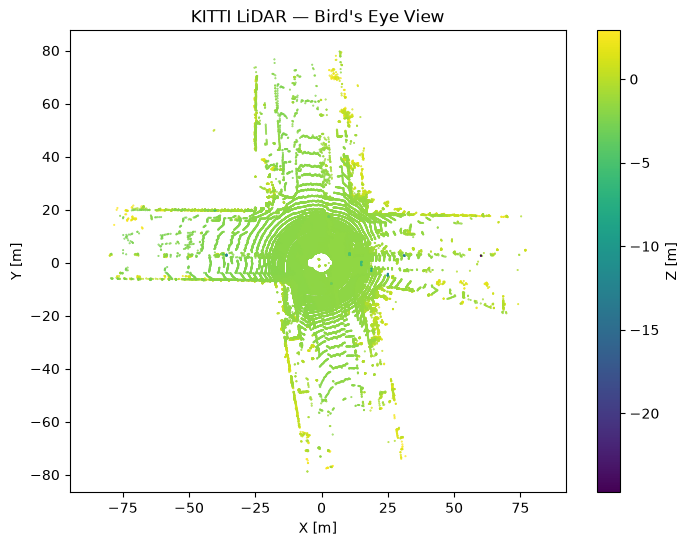

In [75]:
import matplotlib.pyplot as plt
# Bird's eye view
plt.figure(figsize=(8, 6))

plt.scatter(
    xyz[:, 0],
    xyz[:, 1],
    s=0.2,
    c=xyz[:, 2]
)

plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("KITTI LiDAR — Bird's Eye View")
plt.axis("equal")
plt.colorbar(label="Z [m]")
plt.show()

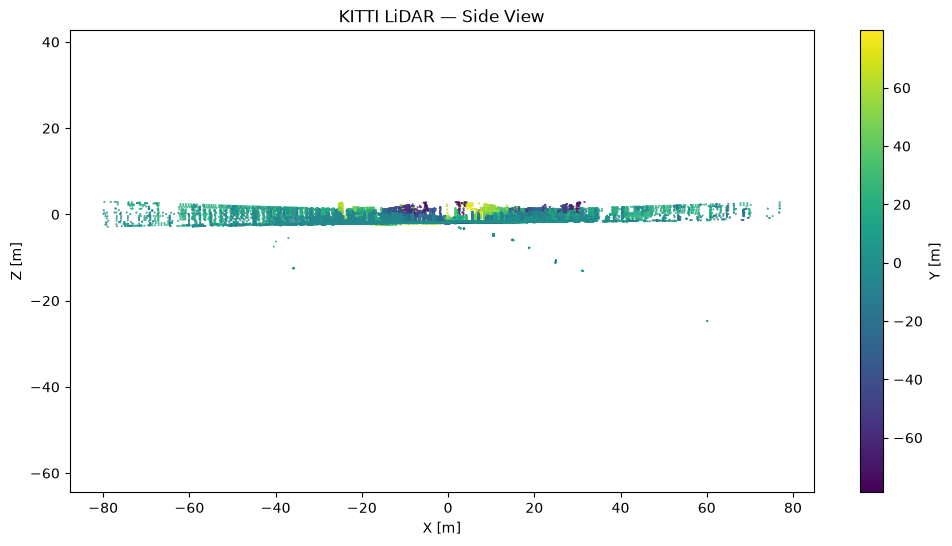

In [76]:
# side view
plt.figure(figsize=(12, 6))

plt.scatter(
    xyz[:, 0],
    xyz[:, 2],
    s=0.2,
    c=xyz[:, 1]
)

plt.xlabel("X [m]")
plt.ylabel("Z [m]")
plt.title("KITTI LiDAR — Side View")
plt.axis("equal")
plt.colorbar(label="Y [m]")
plt.show()

In [84]:
# 3D Visualization with Open3D
import open3d as o3d

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)

viewer_uid = o3d.visualization.draw(
    [pcd],
    title="KITTI LiDAR - Interactive 3D View",
    width=1000,
    height=700,
    point_size=2,
    non_blocking_and_return_uid=True,
)

viewer_uid

[Open3D INFO] Window window_5 created.


'window_5'

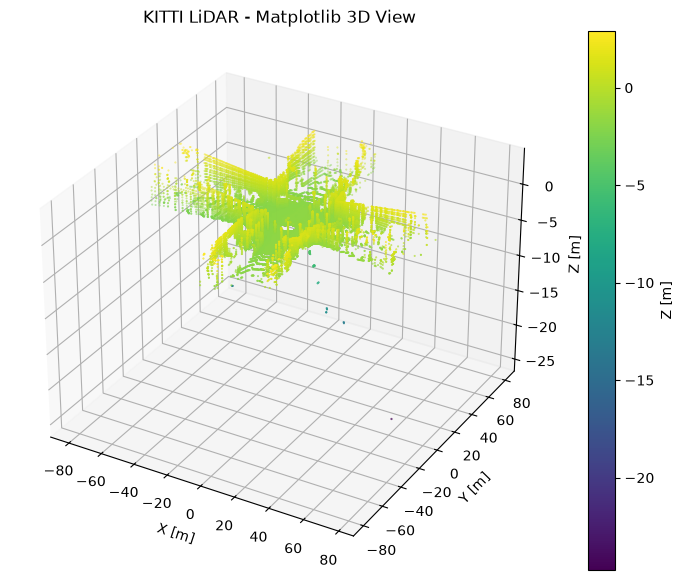

In [85]:
# 3D Visualization with Matplotlib
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    xyz[:, 0],
    xyz[:, 1],
    xyz[:, 2],
    s=0.2,
    c=xyz[:, 2],
    cmap="viridis",
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_zlabel("Z [m]")
ax.set_title("KITTI LiDAR - Matplotlib 3D View")
fig.colorbar(scatter, ax=ax, label="Z [m]")
plt.show()